In [29]:
import numpy as np
import random
from scipy import constants
import matplotlib.pyplot as plt

def tx_signal(f, f_c, fs, burst_len):
  """
  Generates the transmitted signal for a continuous wave radar.

  Args:
    f: The baseband frequency in Hz.
    f_c: The carrier frequency in Hz.
    fs: The sampling rate in Hz.
    burst_len: The number of samples in the pulse.

  Returns:
    A numpy array of complex numbers representing the transmitted signal.
  """

  t = np.arange(burst_len) / fs
  baseband = np.exp(2j * np.pi * f * t)
  initial_phase = random.uniform(0, 2 * np.pi)  # Generate a random initial phase between 0 and 2pi
  carrier = np.exp(2j * np.pi * f_c * (t + initial_phase))
  tx = baseband * carrier
  return tx, baseband

def echo_amplitude(f_c, d, c, rcs):
  """
  Calculates the amplitude of the radar echo signal.

  Args:
    f: The baseband frequency in Hz.
    f_c: The carrier frequency in Hz.
    fs: The sampling rate in Hz.
    burst_len: The number of samples in the pulse.
    d: The distance to the object in meters.
    c: The speed of light in meters per second.
    rcs: The radar cross-section of the object in square meters.

  Returns:
    The amplitude of the radar echo signal.
  """

  # Calculate the transmitted power.
  pt = 20  # Assume that the transmitted power is 1 watt.

  # Calculate the received power.
  wavelength = c / f_c
  received_power = (pt * 10 * 10 * wavelength**2) / ((4 * np.pi * d)**2)
  # received_power = (pt * rcs) / ((4 * np.pi)**2 * d**4 )
  #   pr = (pt * gt * gr * wavelength**2) / ((4 * np.pi * r)**2 * l)

  # Calculate the amplitude of the echo signal.
  amplitude = np.sqrt(received_power)

  return amplitude

def echo_signal(f, f_c, fs, burst_len, d, c, sigma):
    """
    Generates the echo signal for a continuous wave radar with a random initial phase for the carrier.
    
    Args:
    f: The baseband frequency in Hz.
    f_c: The carrier frequency in Hz.
    fs: The sampling rate in Hz.
    burst_len: The number of samples in the pulse.
    d: The distance to the object in meters.
    c: The speed of light in meters per second.
    
    Returns:
    A numpy array of complex numbers representing the echo signal.
    """
    
    t = np.arange(burst_len) / fs
    delay = 2 * d / c  # Time delay for the signal to travel to the object and back
    amp = echo_amplitude(f_c, d, constants.c, 1)
    amp = 0.5
    noise = sigma * (np.random.randn(burst_len) + 1j * np.random.randn(burst_len)) / np.sqrt(2)  # Generate complex Gaussian noise
    echo = amp*np.exp(2j*np.pi*f*t) * np.exp(-2j*np.pi*f_c*delay) + noise
    tx = np.exp(2j*np.pi*f*t)
    return echo, tx

-2.6743629257876793


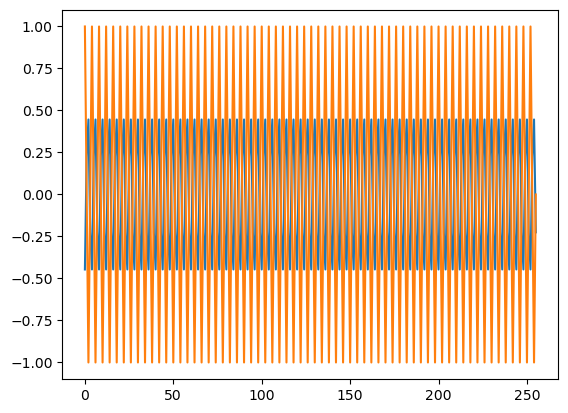

In [30]:
f = 500e3  # Hz
f_c = 2e9  # Hz
fs = 2e6  # Hz
burst_len = 2**8
d = 10

echo, tx = echo_signal(f, f_c, fs, burst_len, d, constants.c, sigma=0)
plt.plot(np.real(echo))
plt.plot(np.real(tx))

print(np.angle(np.mean(echo/tx)))

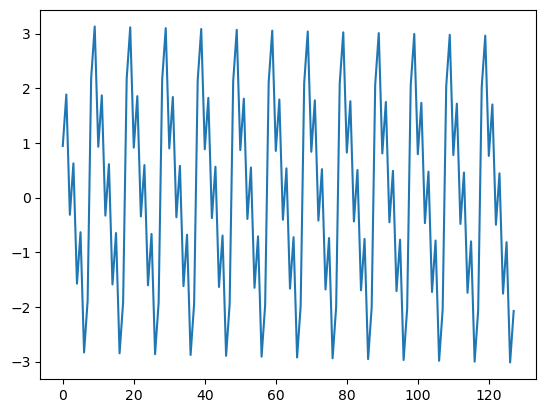

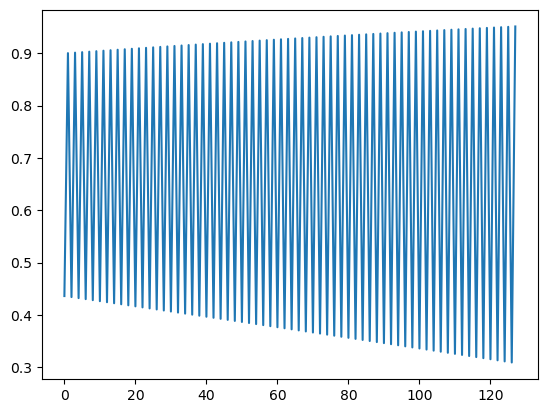

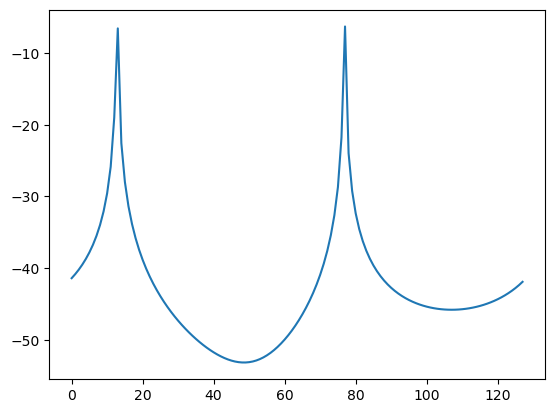

In [31]:
start_freq = 2e9
step_size = 30e6
f = 500e3  # Hz
fs = 5e6  # Hz
burst_len = 2**10
target_list = [0.5,3]

fc_plan = []
for i in range(128):
    fc_plan.append(start_freq + i*step_size)

ch_responses = []
for f_c in fc_plan:
    echo_list = []
    for d in target_list:
        echo, tx = echo_signal(f, f_c, fs, burst_len, d, constants.c, sigma=0)
        echo_list.append(echo)
    echo_list = np.array(echo_list)
    #print(echo_list.shape)
    echo_final = np.sum(echo_list,axis=0)
    #print(echo_final.shape)
    ch_responses.append(echo_final/tx)

ch_responses = np.array(ch_responses)
ch_responses = np.mean(ch_responses,axis=1)
plt.plot(np.angle(ch_responses))
plt.figure()
plt.plot(np.abs(ch_responses))
plt.figure()
range_profile = np.fft.ifft(ch_responses)
plt.plot(10*np.log10(np.abs(range_profile)**2))

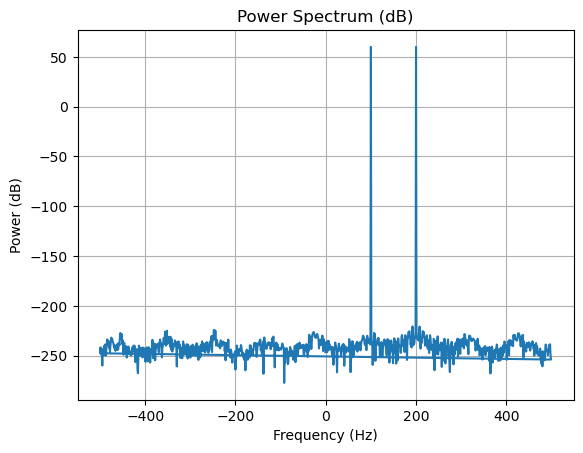

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def power_spectrum_db(signal, fs):
  """
  Calculates the power spectrum of a given complex signal in dB.

  Args:
    signal: A numpy array of complex numbers representing the signal.
    fs: The sampling rate in Hz.

  Returns:
    A tuple containing two numpy arrays:
      - freqs: The frequencies corresponding to the power spectrum.
      - power_db: The power spectrum of the signal in dB.
  """

  N = len(signal)  # Length of the signal
  fft = np.fft.fft(signal)  # Compute the FFT of the signal
  freqs = np.fft.fftfreq(N, 1/fs)  # Compute the frequencies
  power = np.abs(fft)**2  # Compute the power spectrum
  power_db = 10 * np.log10(power)  # Convert to dB

  return freqs, power_db

# Example usage:
# Generate a complex signal with two sinusoids
fs = 1000  # Sampling rate
t = np.arange(0, 1, 1/fs)  # Time vector
f1 = 100  # Frequency of the first sinusoid
f2 = 200  # Frequency of the second sinusoid
signal = np.exp(2j*np.pi*f1*t) + np.exp(2j*np.pi*f2*t)

# Calculate the power spectrum in dB
freqs, power_db = power_spectrum_db(signal, fs)

# Plot the power spectrum in dB
plt.plot(freqs, power_db)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (dB)')
plt.title('Power Spectrum (dB)')
plt.grid()
plt.show()

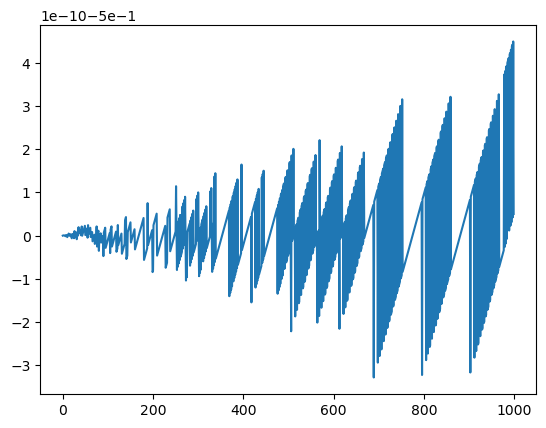

In [93]:
f = 1e9  # Hz
fs = 2e6  # Hz
burst_len = 1000
d = 100  # meters
c = 3e8  # meters per second

echo = echo_signal(f, fs, burst_len, d, c)

# Plot the echo signal
import matplotlib.pyplot as plt
plt.plot(np.real(echo))
